In [2]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join('..', 'shape_representation'))
sys.path.insert(0, os.path.join('..', 'femm_automation'))
sys.path.insert(0, os.path.join('..', 'genetic_algorithm'))

from ngn import make_grid, make_centers, ngn_density, threshold
from rbf import rbf_density, normalize
from simulator import simulate
from ga import run_ga
from pipeline import make_fitness_fn

In [3]:
fitness_ngn = make_fitness_fn(method='ngn', N_side=4, sigma=0.2, tau=0.5)

best_w_ngn, best_f_ngn, hist_best_ngn, hist_avg_ngn = run_ga(
    fitness_fn    = fitness_ngn,
    n_weights     = 16,
    pop_size      = 15,
    n_generations = 20,
    mutation_rate = 0.1,
    seed          = 42
)

print(f'\nNGN best flux linkage: {best_f_ngn:.6f} Wb')

Gen   1 | best=0.007267 | avg=0.002387
Gen   2 | best=0.007325 | avg=0.004113
Gen   3 | best=0.008248 | avg=0.005306
Gen   4 | best=0.008540 | avg=0.005828
Gen   5 | best=0.008540 | avg=0.006947
Gen   6 | best=0.008540 | avg=0.006584
Gen   7 | best=0.008733 | avg=0.007845
Gen   8 | best=0.008733 | avg=0.007596
Gen   9 | best=0.008733 | avg=0.008049
Gen  10 | best=0.008733 | avg=0.008490
Gen  11 | best=0.008733 | avg=0.008496
Gen  12 | best=0.008733 | avg=0.008697
Gen  13 | best=0.008733 | avg=0.008471
Gen  14 | best=0.008733 | avg=0.008315
Gen  15 | best=0.008733 | avg=0.008230
Gen  16 | best=0.008733 | avg=0.008288
Gen  17 | best=0.008733 | avg=0.008524
Gen  18 | best=0.008733 | avg=0.008141
Gen  19 | best=0.008733 | avg=0.008194
Gen  20 | best=0.008733 | avg=0.008139

NGN best flux linkage: 0.008733 Wb


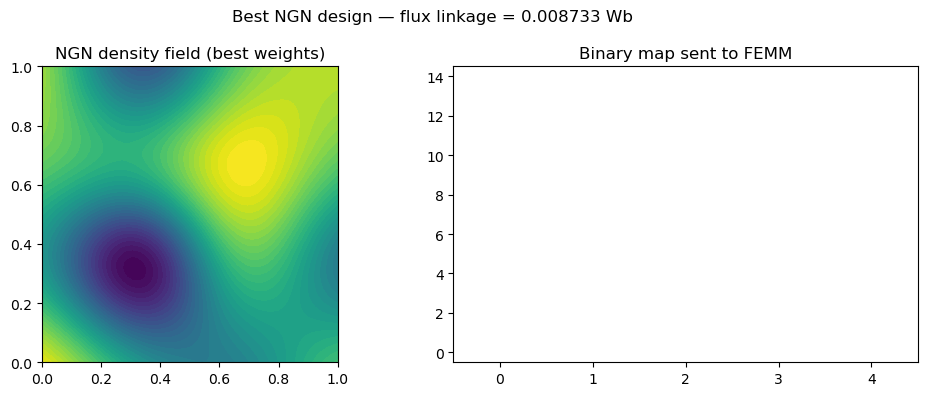

In [4]:
XX, YY  = make_grid(60)
centers = make_centers(4)

rho_best = ngn_density(best_w_ngn, XX, YY, centers, sigma=0.2)
B_best   = threshold(rho_best, tau=0.5)

from skimage.transform import resize
B_femm = resize(B_best, (15, 5), order=0, anti_aliasing=False)
B_femm = (B_femm > 0.5).astype(float)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].contourf(XX, YY, rho_best, levels=50, cmap='viridis')
axes[0].set_title('NGN density field (best weights)')
axes[0].set_aspect('equal')

axes[1].imshow(B_femm, cmap='gray_r', origin='lower')
axes[1].set_title('Binary map sent to FEMM')
axes[1].set_aspect('auto')

plt.suptitle(f'Best NGN design — flux linkage = {best_f_ngn:.6f} Wb')
plt.tight_layout()
plt.savefig('best_shape_ngn.png')
plt.show()